## <center> **FDC104: Programming For Scientific Computing And Data Analysis**
## <center> **Final Project**
## <center> **Group 7**
# <center> Dataset 7: Company X Loan History Data Set
---

# **Abstract**

- Bộ dữ liệu được cung cấp bởi Công ty X - kinh doanh tất cả các khoản cho vay mua nhà. Công ty có mặt ở khắp các khu vực thành thị, bán thành thị và nông thôn. Cách thức hoạt động: Khách hàng trước tiên đăng ký khoản vay mua nhà sau đó công ty xác nhận các điều kiện của khách hàng đối với khoản vay từ đó đưa ra chấp thuận có cho vay hay không.
- Mục tiêu phân tích: 

> Giải thích các yếu tố liên quan ảnh hưởng đến quyết định cho vay mua nhà

> Xây dựng mô hình có thể giúp công ty X tự động hóa quy trình phê duyệt khoản vay -> Từ đó, rút ra kết luận về cách phê duyệt khoản vay mua nhà của một người

- Tệp dữ liệu gồm 13 biến liên quan đến việc xác định khả năng vay mượn của khách hàng, tuy nhiên, sau quá trình EDA, nhóm chỉ ra được 7 biến có ảnh hưởng sâu sắc hơn đến quyết định cho vay của công ty X, bao gồm: Marital Status, Education, Credit History, Property_Area, ApplicantIncome, CoapplicantIncome, LoanAmount. Nhóm sẽ dựa vào 7 biến trên để xây dựng mô hình dự đoán biến Loan_Status.

- Về việc xây dựng mô hình, nhóm lựa chọn 6 loại mô hình để đưa ra dự đoán, lần lượt là Logistic Regression, Decision Tree, XGBoost Classifier, KNeighbours, SVM, AdaBoost. Để chọn ra mô hình có thể đưa ra dự đoán tốt nhất, nhóm sử dụng 4 metrics Accuracy, Precision, Recall, AUC để so sánh. Kết quả cho thấy mô hình Decision Tree có chỉ số Accuracy tốt hơn so với 4 models còn lại. Hơn nữa, Decision Tree có Precision và AUC cao hơn so với Logistic Regression. Vì vậy, Decision Tree là mô hình được nhóm lựa chọn để đưa ra dự đoán về tình trạng vay cho khách hàng mới

# **Outline:**
1. Data Preprocessing
- 1.1. Xử lý misssing data
- 1.2. Xử lý Dữ Liệu Ngoại Lai
2. Exploratory Data Analysis (EDA)
- 2.1.Correlation
- 2.2. Descriptive Statistics
- 2.3. Identify important variable
3. Model
- 3.1.Logistic Regression
- 3.2.Decision Tree
- 3.3.XGBoost Classifier
- 3.4.KNeighbours
- 3.5.SVM
- 3.6.AdaBoost Classifier
- 3.7. So sánh Models
4. Tài liệu tham khảo

# 1. Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv('company-x-loan.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


### 1.1. Xử lý misssing data

In [5]:
missing_data = df.isnull()
missing_data.columns.values.tolist()

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

In [6]:
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")

Loan_ID
False    614
Name: Loan_ID, dtype: int64

Gender
False    601
True      13
Name: Gender, dtype: int64

Married
False    611
True       3
Name: Married, dtype: int64

Dependents
False    599
True      15
Name: Dependents, dtype: int64

Education
False    614
Name: Education, dtype: int64

Self_Employed
False    582
True      32
Name: Self_Employed, dtype: int64

ApplicantIncome
False    614
Name: ApplicantIncome, dtype: int64

CoapplicantIncome
False    614
Name: CoapplicantIncome, dtype: int64

LoanAmount
False    592
True      22
Name: LoanAmount, dtype: int64

Loan_Amount_Term
False    600
True      14
Name: Loan_Amount_Term, dtype: int64

Credit_History
False    564
True      50
Name: Credit_History, dtype: int64

Property_Area
False    614
Name: Property_Area, dtype: int64

Loan_Status
False    614
Name: Loan_Status, dtype: int64



Có tất cả 614 hàng dữ liệu, trong đó:

- “Gender”: thiếu 13 dữ liệu
- “Married”: Thiếu 3 dữ liệu
- "Dependents": thiếu 15 dữ liệu
- "Self_Employed" : thiếu 32 dữ liệu
- "Loan_Amount": 22 dữ liệu bị thiếu
- "Loan_Amount_Term": thiếu 14 dữ liệu
- "Credit_History": 50 dữ liệu bị thiếu

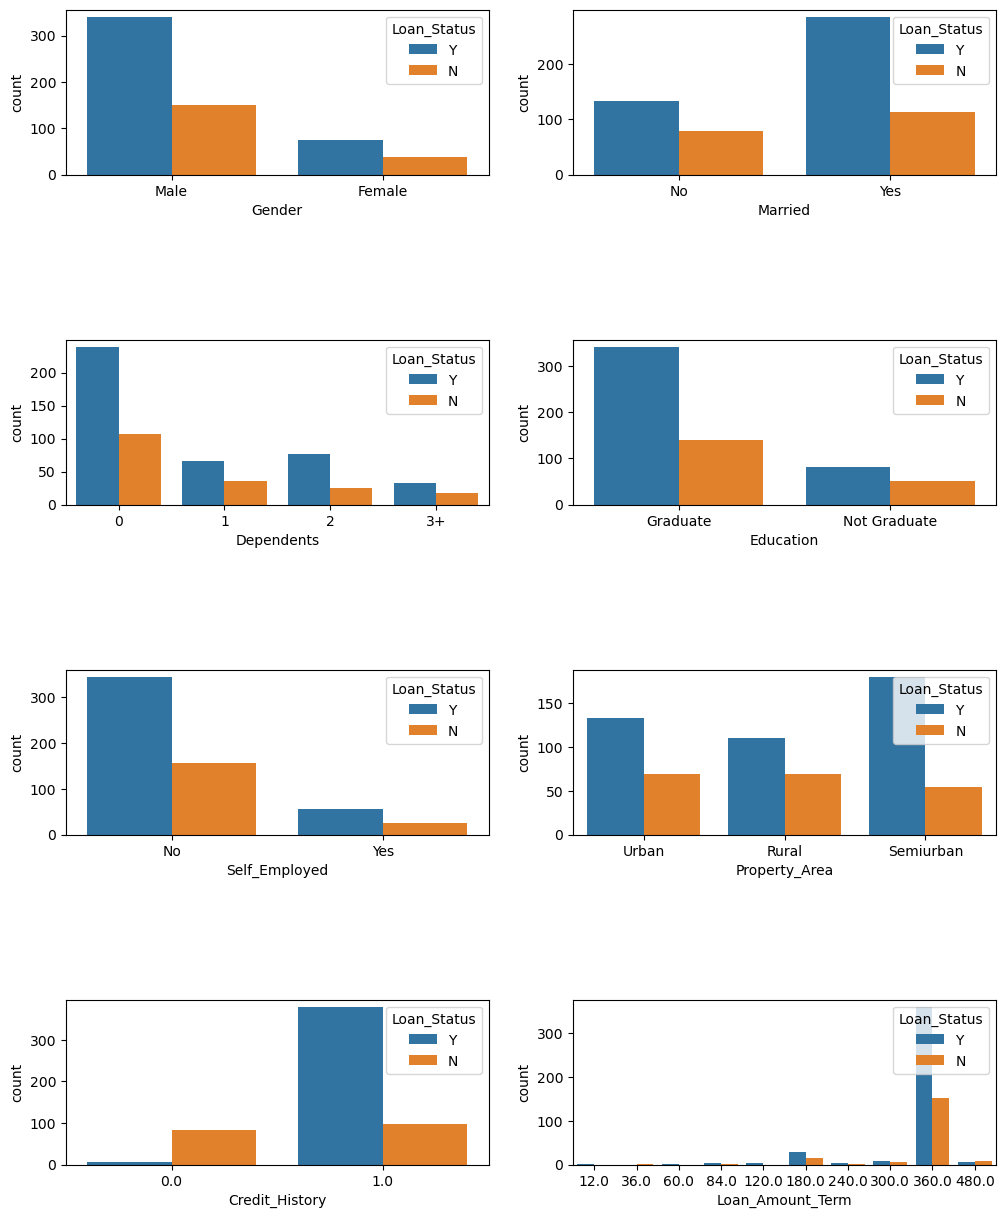

In [7]:
#Visualizing categorical variables
categorical_columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area','Credit_History','Loan_Amount_Term']
fig,axes = plt.subplots(4,2,figsize=(12,15))
for idx,cat_col in enumerate(categorical_columns):
    row,col = idx//2,idx%2
    sns.countplot(x=cat_col,data=df,hue='Loan_Status',ax=axes[row,col])


plt.subplots_adjust(hspace=1)

Trực quan bằng biểu đồ boxplot: các dữ liệu ApplicantIncome, CoapplicantIncome, LoanAmount

       ApplicantIncome  CoapplicantIncome  LoanAmount
count       614.000000         614.000000  592.000000
mean       5403.459283        1621.245798  146.412162
std        6109.041673        2926.248369   85.587325
min         150.000000           0.000000    9.000000
25%        2877.500000           0.000000  100.000000
50%        3812.500000        1188.500000  128.000000
75%        5795.000000        2297.250000  168.000000
max       81000.000000       41667.000000  700.000000


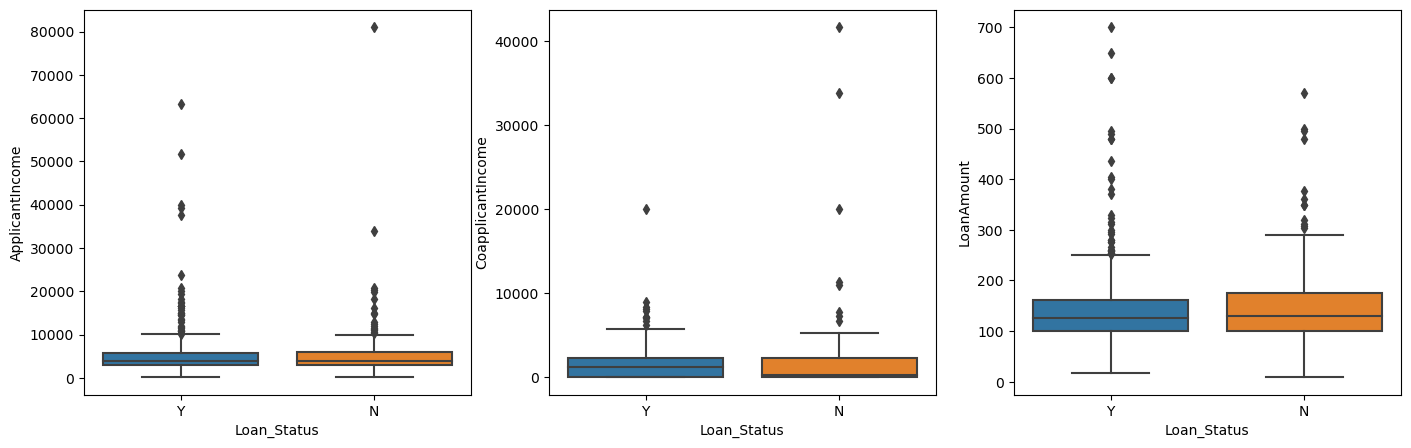

In [8]:
#Visualizing numerical variables
numerical_columns = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
fig,axes = plt.subplots(1,3,figsize=(17,5))
for idx,cat_col in enumerate(numerical_columns):
    sns.boxplot(y=cat_col,data=df,x='Loan_Status',ax=axes[idx])

print(df[numerical_columns].describe())
plt.subplots_adjust(hspace=1)

Thay thế các trường missing trong "Gender" (Mode): Male xuất hiện nhiều hơn với Loan-status: Yes 
> => thay thể missing value = Male

In [9]:
# Thay thế các trường missing trong "Gender" bằng Male
df['Gender'].replace(np.nan, "Male", inplace = True)

Thay thế các trường missing trong "Married" (Mode): Yes xuất hiện nhiều hơn với Loan-status: Yes 
> => thay thể missing value = Yes

In [10]:
# Thay thế các trường missing trong "Married" bằng Yes
df['Married'].replace(np.nan, "Yes", inplace = True)

Thay thế các trường missing trong "Dependents" (Mode): 0 xuất hiện nhiều hơn với Loan-status: Yes 
> => thay thể missing value = 0

In [11]:
# Thay thế các trường missing trong "Dependents" bằng 0
df['Dependents'].replace(np.nan, '0', inplace = True)

Thay thế các trường missing trong "self_employed data" (Mode):  No xuất hiện nhiều hơn với Loan-status: Yes 
> => thay thể missing value = NO

In [12]:
# Thay thế các trường missing trong "Self_Employed" bằng No
df['Self_Employed'].replace(np.nan, "No", inplace = True)

Thay thế các trường missing trong "Loan_Amount_Term" (Mode):  Dựa trên tần suất xuất hiện: 360.0 xuất hiện nhiều nhất
> => thay thể missing value = 360.0

In [13]:
# kiểm tra mode của 'Loan_Amount_Term'
df['Loan_Amount_Term'].value_counts()

360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: Loan_Amount_Term, dtype: int64

In [14]:
# Thay thế các trường missing trong "Loan_Amount_Term" bằng 360
df['Loan_Amount_Term'].replace(np.nan, 360, inplace = True)

Thay thế các trường missing trong "Credit_History" (Mode): Dựa trên tần suất xuất hiện: 1.0 xuất hiện nhiều nhất
> => thay thể missing value = 1.0

In [15]:
df['Credit_History'].value_counts()

1.0    475
0.0     89
Name: Credit_History, dtype: int64

In [16]:
# Thay thế các trường missing trong "Credit_History" bằng 1
df['Credit_History'].replace(np.nan, 1, inplace = True)

clean Loan_Amount data:

In [17]:
df1 = df.loc[:, ['LoanAmount']]

imp = IterativeImputer(RandomForestRegressor(), max_iter=10, random_state = 0)
df1 = pd.DataFrame(imp.fit_transform(df1), columns=df1.columns)

df['LoanAmount'] = df1['LoanAmount']

Kiểm tra xem còn null không

In [18]:
df.isnull().sum() #recheck null values

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [19]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.000000,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.000000,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.000000,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.000000,360.0,1.0,Urban,Y


### 1.2. Xử lý Dữ Liệu Ngoại Lai

Nhìn vào sự phân bổ 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', chúng tôi thấy rằng có rất nhiều giá trị ngoại lai.



In [20]:
df[(df['ApplicantIncome']>10000)].sort_values(by='ApplicantIncome', ascending=False)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
409,LP002317,Male,Yes,3+,Graduate,No,81000,0.0,360.000000,360.0,0.0,Rural,N
333,LP002101,Male,Yes,0,Graduate,No,63337,0.0,490.000000,180.0,1.0,Urban,Y
171,LP001585,Male,Yes,3+,Graduate,No,51763,0.0,700.000000,300.0,1.0,Urban,Y
155,LP001536,Male,Yes,3+,Graduate,No,39999,0.0,600.000000,180.0,0.0,Semiurban,Y
185,LP001640,Male,Yes,0,Graduate,Yes,39147,4750.0,120.000000,360.0,1.0,Semiurban,Y
443,LP002422,Male,No,1,Graduate,No,37719,0.0,152.000000,360.0,1.0,Semiurban,Y
183,LP001637,Male,Yes,1,Graduate,No,33846,0.0,260.000000,360.0,1.0,Semiurban,N
126,LP001448,Male,Yes,3+,Graduate,No,23803,0.0,370.000000,360.0,1.0,Rural,Y
506,LP002624,Male,Yes,0,Graduate,No,20833,6667.0,480.000000,360.0,1.0,Urban,Y
284,LP001922,Male,Yes,0,Graduate,No,20667,0.0,146.412162,360.0,1.0,Rural,N


> Xem xét dòng đầu tiên, mặc dù ApplicantIncome rất lớn nhưng trạng thái phê duyệt khoản vay là Không. Khi xem xét các đặc điểm khác của mục này, ta thấy Credit_History = 0, nghĩa là nó không đạt được nguyên tắc của công ty.

>=> Những giá trị ngoại lai này mang lại cái nhìn sâu sắc hơn về giá trị khách quan nên được giữ lại. Ngoài ra số lượng giá trị ngoại lai là quá cao và nhìn vào biểu đồ boxplot, ta thấy rằng các giá trị ngoại lai dường như không ảnh hưởng quá nhiều đến Loan_Status.

# 2. Exploratory Data Analysis (EDA)

### 2.1.Correlation

Do mục tiêu của nhóm là dự đoán về Loan Status nên trong phần này, nhóm dự định sẽ lọc ra correlation của biến này với các biến còn lại trong bộ dữ liệu

In [21]:
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Married']= df['Married'].map({'Yes': 1, 'No': 0})
df['Property_Area'] = df['Property_Area'].map({'Urban': 0, 'Semiurban': 2, 'Rural': 1})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df['Dependents']= df['Dependents'].map({'3+': 3,'1':1,'0':0,'2':2})

In [22]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,1,0,5849,0.0,146.412162,360.0,1.0,0,1
1,LP001003,1,1,1,1,0,4583,1508.0,128.000000,360.0,1.0,1,0
2,LP001005,1,1,0,1,1,3000,0.0,66.000000,360.0,1.0,0,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.000000,360.0,1.0,0,1
4,LP001008,1,0,0,1,0,6000,0.0,141.000000,360.0,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0,1,0,2900,0.0,71.000000,360.0,1.0,1,1
610,LP002979,1,1,3,1,0,4106,0.0,40.000000,180.0,1.0,1,1
611,LP002983,1,1,1,1,0,8072,240.0,253.000000,360.0,1.0,0,1
612,LP002984,1,1,2,1,0,7583,0.0,187.000000,360.0,1.0,0,1


In [23]:
# Bỏ cột Loan_ID trong DataFrame gốc
df_new = df.drop(columns=['Loan_ID'])
# Tính toán tương quan sau khi loại bỏ các cột
correlation = df_new.corr()['Loan_Status'].to_frame().style.background_gradient(cmap='RdPu').format(precision=2)
correlation

,Loan_Status
Gender,0.02
Married,0.09
Dependents,0.01
Education,0.09
Self_Employed,-0.00
ApplicantIncome,-0.00
CoapplicantIncome,-0.06
LoanAmount,-0.04
Loan_Amount_Term,-0.02
Credit_History,0.54


Có thể thấy rằng, biến Credit_History có correlation(mối tương quan khá tốt) với Loan_Status (0.54)

=> Biến này có mối quan hệ khá mạnh, ảnh hưởng tương đối đến Tình trạng cho vay

Nhóm tiếp tục dùng Heatmap để có đánh giá tốt hơn

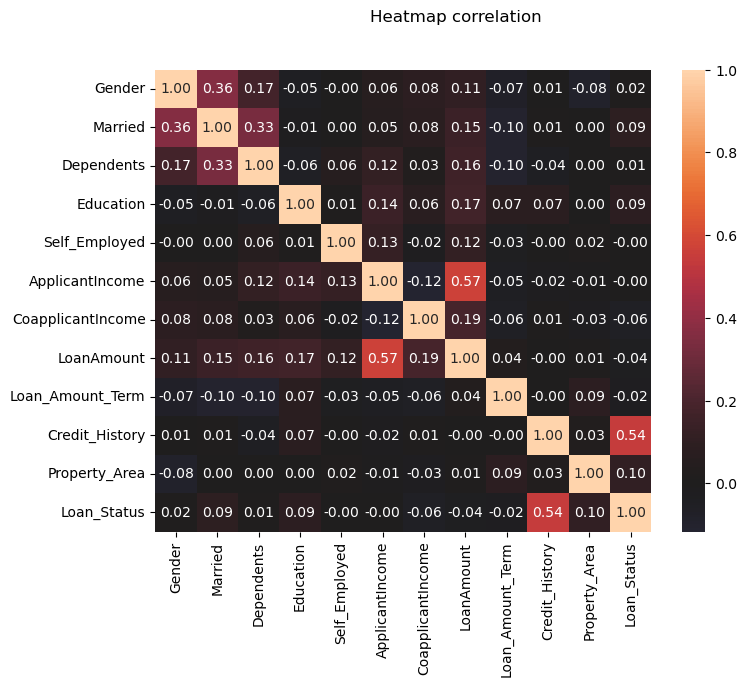

In [24]:
#heatmap corr
corr=df_new.select_dtypes(include=['float','int']).corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True, fmt=".2f", center=0, cmap="icefire")
plt.suptitle('Heatmap correlation')
plt.show()

Hầu hết, khi xét đến mối quan hệ với Loan_Status, các biến có correlation khá nhỏ, ít ảnh hưởng đến Loan Status. Ngược lại, biến Credit_History có mối tương quan chặt chẽ với khả năng có được chấp thuận khoản vay của khách hàng

Tuy nhiên, khi xét các biến khác, một số biến có mối tương quan tuy nhỏ như Property_Area, Marital Status hay Education cũng được nhóm thêm vào để dự đoán sự ảnh hưởng đến tình trạng các khoản cho vay

### 2.2. Descriptive Statistics

Nhóm sử dụng các biểu đồ như histogram và bar chart để nhận xét về các biến

Với các biến liên tục, nhóm sử dụng histogram để hiểu rõ hơn về dữ liệu

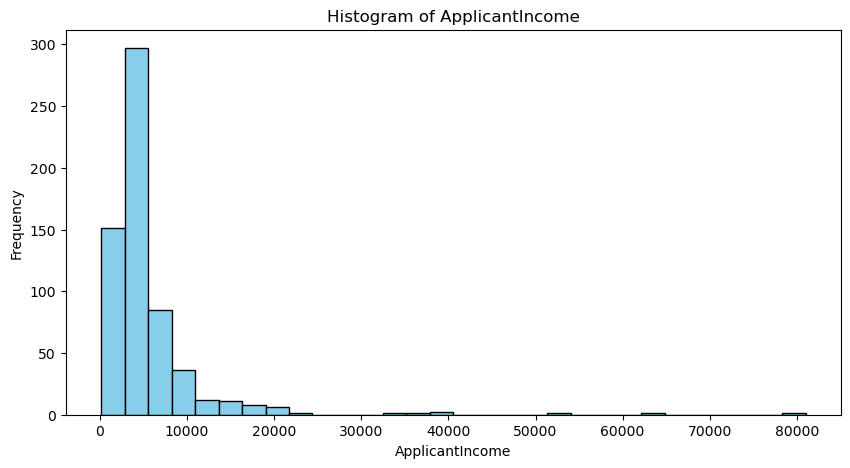

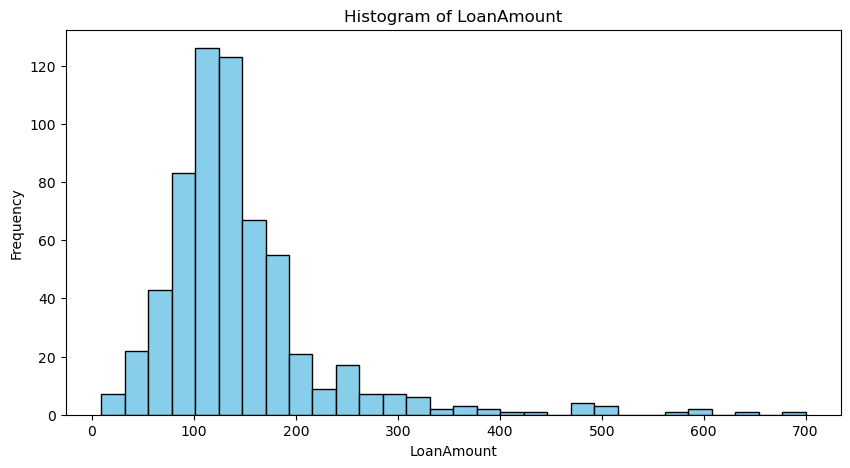

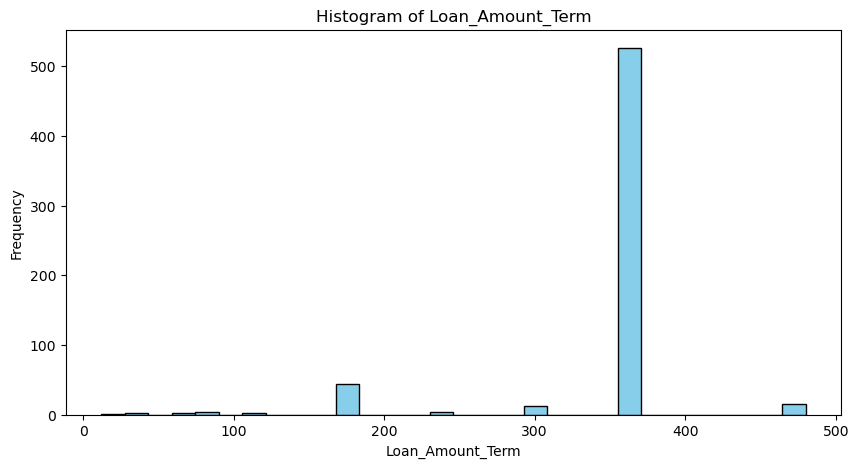

In [25]:
cols_to_plot = ['ApplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# Vẽ histogram cho mỗi cột
for col in cols_to_plot:
    plt.figure(figsize=(10, 5))
    plt.hist(df_new[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Khi xét đến các **biến liên tục**,

**ApplicantIncome**: Có thấy có sự biến động lớn trong thu nhập của người nộp đơn khi độ lệch chuẩn cao.Thu nhập của người nộp đơn nằm trong khoảng từ 150 đến 81000. Đa số người nộp đơn xét duyệt cho vay có thu nhập ở mức 150 và 300

**LoanAmount**: Số tiền vay nằm trong khoảng từ 9 đến 700 và số tiền vay được nhiều người chọn nhất nằm ở mức 120

**Loan_Amount_Term**: Thời hạn vay nằm trong khoảng từ 12 đến 480.


Một số cột dưới đây được nhóm sử dụng bar chart để đánh giá


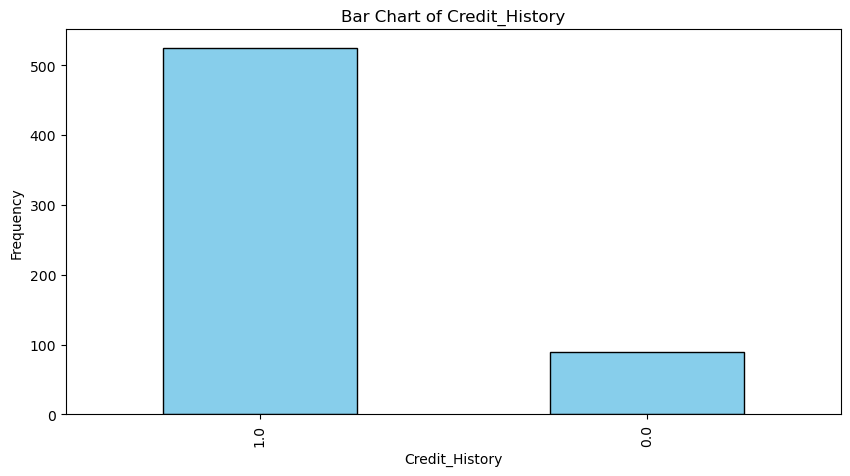

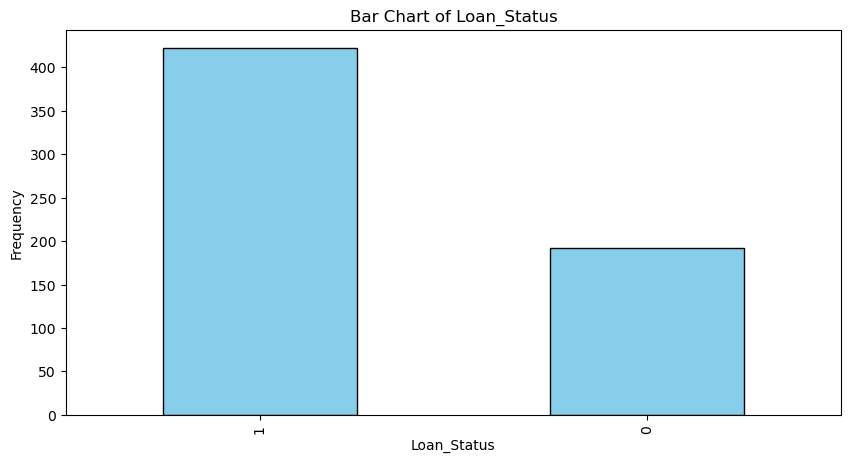

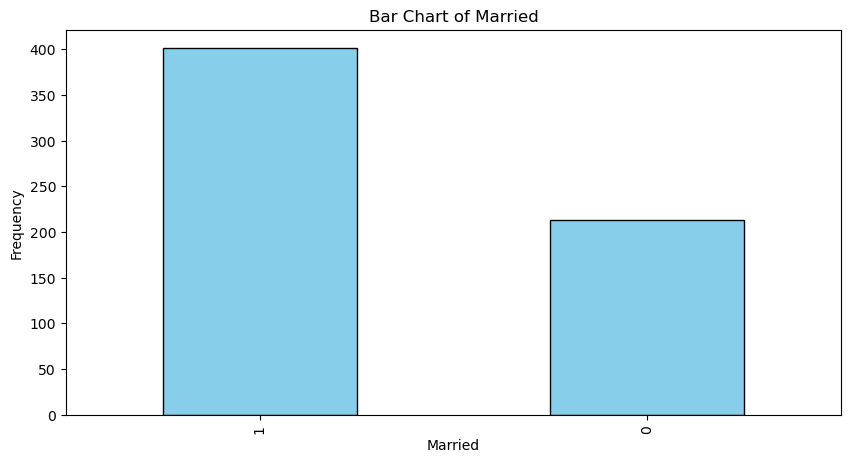

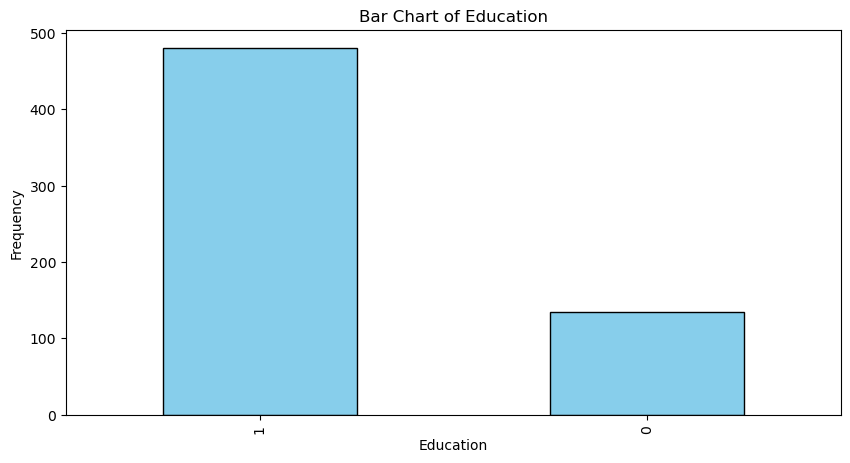

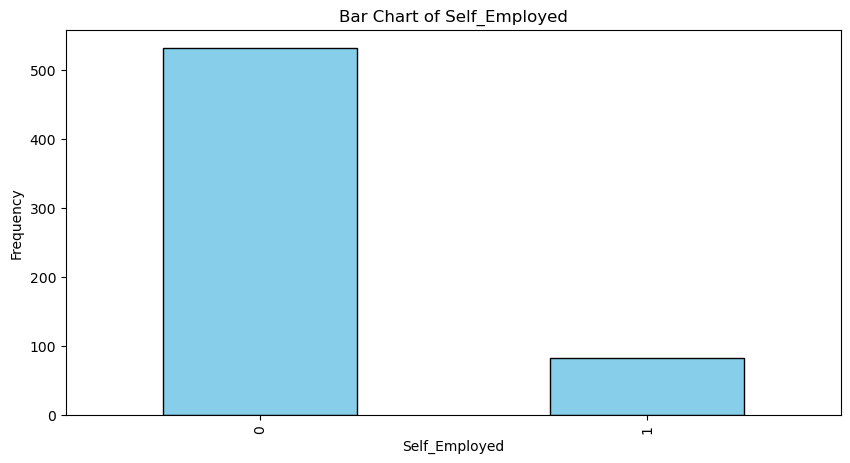

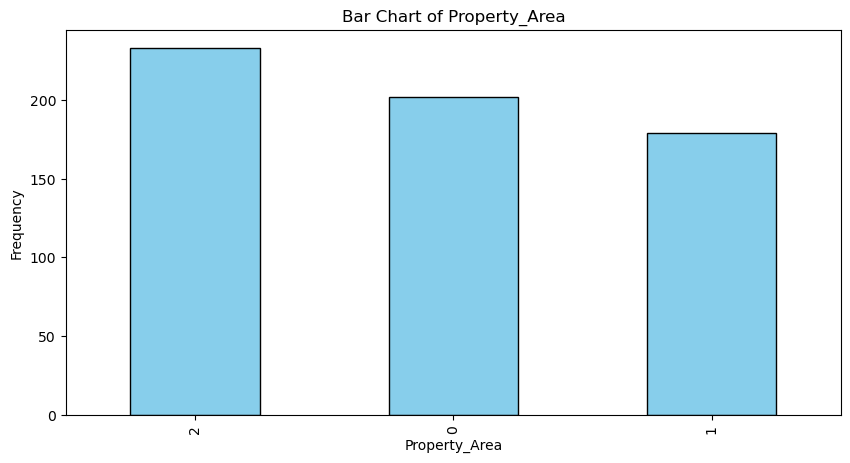

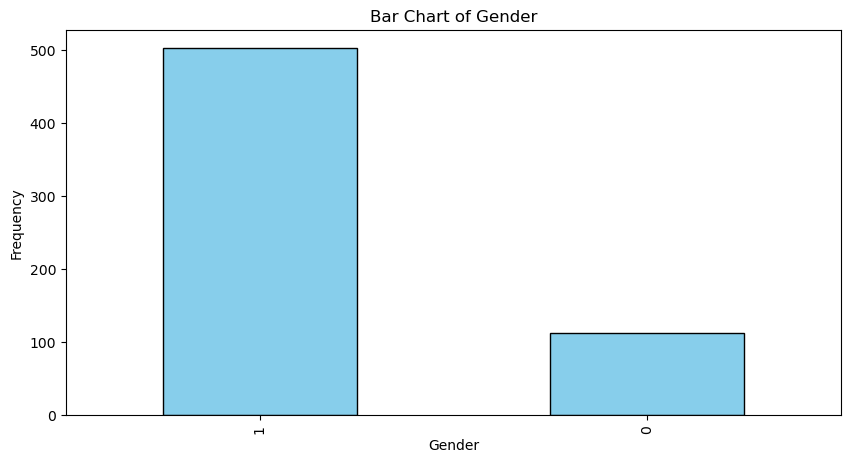

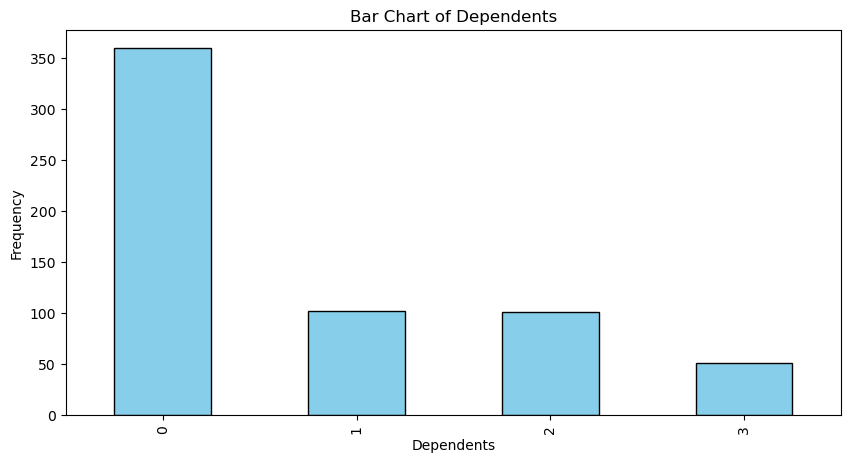

In [26]:
cols_to_plot = [ 'Credit_History', 'Loan_Status','Married','Education','Self_Employed','Property_Area','Gender','Dependents']

# Vẽ biểu đồ cột cho mỗi cột
for col in cols_to_plot:
    plt.figure(figsize=(10, 5))
    df_new[col].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Với các biến này, nhóm có nhận xét như sau:

**Married**:Hầu hết người nộp xét duyệt khoản vay đã kết hôn.

**Education**: Hầu hết người vay đã tốt nghiệp.

**Self_Employed**: Chỉ một phần nhỏ người đi vay là tự kinh doanh.

**Credit_History**: Hầu hết các người đáp ứng đủ điều kiện vay có lịch sử tín dụng tốt.

**Property_Area**: Cho thấy sự phân bố đều giữa các khu vực.

**Gender**:Số lượng người vay là nam chiếm đa số trong bộ dữ liệu.

**Dependents**: Những người đi vay thường có 1 người phụ thuộc hoặc không có người phụ thuộc nào. Có thể kết luận rằng người đi vay thường là những cặp vợ chồng có một con hoặc chưa từng sinh con hoặc là người chưa kết hôn

### 2.3. Identify important variable

Xác định xem biến nào quan trọng thông qua chỉ số The Pearson Correlation Coefficient và P-value

In [27]:
df.shape[1]

13

In [28]:
import scipy.stats as stats
for i in range(2,13):
    pearson_coef, p_value = stats.pearsonr(df[df.columns[i]], df['Loan_Status'])
    print(f"The Pearson Correlation Coefficient - {df.columns[i]} is", pearson_coef, " with a P-value of P =", p_value,
          '\n', '---------')



The Pearson Correlation Coefficient - Married is 0.09147782473606011  with a P-value of P = 0.023398362796622007 
 ---------
The Pearson Correlation Coefficient - Dependents is 0.010118454497004584  with a P-value of P = 0.8024165133443726 
 ---------
The Pearson Correlation Coefficient - Education is 0.08588391467536512  with a P-value of P = 0.03336067753729137 
 ---------
The Pearson Correlation Coefficient - Self_Employed is -0.003700437714982085  with a P-value of P = 0.9270899835545038 
 ---------
The Pearson Correlation Coefficient - ApplicantIncome is -0.0047095226593515055  with a P-value of P = 0.9072878121306787 
 ---------
The Pearson Correlation Coefficient - CoapplicantIncome is -0.05918731348785013  with a P-value of P = 0.14294828684288485 
 ---------
The Pearson Correlation Coefficient - LoanAmount is -0.036416009972370524  with a P-value of P = 0.36768764508206714 
 ---------
The Pearson Correlation Coefficient - Loan_Amount_Term is -0.02254899350342269  with a P-valu

Đúng như dự đoán từ phần 2.1, các biến có chỉ số Correlation không gần 0 và có P-value < 0.05 như **Marital Status, Education, Credit History và Property_Area** là các biến quan trọng của mô hình

# 3. Model

Đối với loại mô hình mà nhóm sẽ sử dụng, vì Loan_Status là dữ liệu thuộc kiểu categorical, chỉ có hai giá trị là Yes hoặc No, nhóm không thể sử dụng Linear Regression vì Linear Regression dự đoán biến liên tục. Đối với bài toán này, kết quả chỉ có thể là 0 (No) hoặc 1 (Yes) và mọi giá trị khác sẽ không có ý nghĩa. Đối với loại biến này, nhóm sẽ sử dụng Logistic Regression, Decision Tree, AdaBoost, XGBoost, SVM, KNeighbours để dự đoán và đánh giá chúng.

Từ việc đánh giá EDA và Correlation giữa các biến, nhóm đã chỉ ra được 4 biến quan trọng ảnh hưởng đến biến Loan_Status là: **Marital Status, Education, Credit History và Property_Area**. Ngoài ra, từ các research bên ngoài, nhóm nhận thấy thu nhập của người đi vay và giá trị của khoản vay cũng ảnh hưởng sâu sắc đến quyết định cho vay. Vì vậy, nhóm đã chọn ra 7 biến quan trọng nhất để xây dựng mô hình dự đoán quyết định cho vay của ngân hàng: **Marital Status, Education, Credit History, Property_Area, ApplicantIncome, CoapplicantIncome, LoanAmount**  

Để đánh giá performance của 2 model, nhóm dùng 3 metrics: **Accuracy, Precision, AUC Curve**

Có 4 loại dự đoán:

- **True Positive(TP):** mô hình được dự đoán là dương tính và thực tế nó là dương tính

- **True Negative(TN):** mô hình dự đoán âm tính và thực tế nó âm tính

- **False Positive(FP):** mô hình dự đoán là dương tính và thực tế là âm tính

- **False Negative(FN):** mô hình dự đoán âm tính và thực tế là dương tính

**Accuracy:**  đo lường tỷ lệ các dự đoán đúng so với tổng số lượng dự đoán.

𝐴𝑐𝑐𝑢𝑟𝑎𝑐𝑦=(𝑇𝑃+𝑇𝑁)/(𝑇𝑃+𝑇𝑁+𝐹𝑃+𝐹𝑁)

**Precision:** Được tính bằng tỷ lệ giữa số lượng dự đoán đúng positive (True Positives) và tổng số lượng được dự đoán là positive (True Positives + False Positives). Precision đo lường khả năng của mô hình xác định đúng các positive cases.

𝑃𝑟𝑒𝑐𝑖𝑠𝑖𝑜𝑛=𝑇𝑃/(𝑇𝑃+𝐹𝑃)

**AUC:** diện tích dưới đường cong ROC. Trong ngữ cảnh của việc đánh giá hiệu suất của mô hình phân loại (classification model), AUC là một thước đo quan trọng để đánh giá khả năng phân loại của một mô hình dự đoán trên dữ liệu thử nghiệm.

AUC có giá trị nằm trong khoảng từ 0 đến 1:

- **AUC = 1:** Đường cong ROC hoàn hảo, mô hình có khả năng phân loại hoàn toàn chính xác.

- **AUC = 0.5:** Đường cong ROC tương đương với đường chéo, mô hình không có khả năng phân loại tốt hơn ngẫu nhiên.

- **AUC < 0.5:** Đường cong ROC dưới đường chéo, mô hình phân loại tồi hơn ngẫu nhiên.

Một AUC cao thường chỉ ra rằng mô hình có khả năng phân loại tốt, tức là tỷ lệ xác suất của một trường hợp positive được xếp hạng cao hơn so với một trường hợp negative được xếp hạng cao hơn.

AUC là một độ đo hữu ích và thường được sử dụng để so sánh hiệu suất của các mô hình phân loại khác nhau. Nó cung cấp một cái nhìn tổng thể về khả năng phân loại của mô hình trên toàn bộ các ngưỡng quyết định.






### 3.1.Logistic Regression

In [29]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,1,0,5849,0.0,146.412162,360.0,1.0,0,1
1,LP001003,1,1,1,1,0,4583,1508.0,128.000000,360.0,1.0,1,0
2,LP001005,1,1,0,1,1,3000,0.0,66.000000,360.0,1.0,0,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.000000,360.0,1.0,0,1
4,LP001008,1,0,0,1,0,6000,0.0,141.000000,360.0,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0,1,0,2900,0.0,71.000000,360.0,1.0,1,1
610,LP002979,1,1,3,1,0,4106,0.0,40.000000,180.0,1.0,1,1
611,LP002983,1,1,1,1,0,8072,240.0,253.000000,360.0,1.0,0,1
612,LP002984,1,1,2,1,0,7583,0.0,187.000000,360.0,1.0,0,1


In [30]:
# Model for all variables
X = df_new[['Married', 'Education', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Credit_History', 'Property_Area']]
Y = df_new['Loan_Status']

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state =12)

81.62


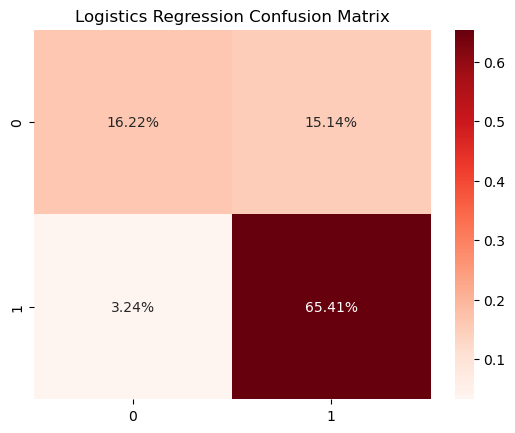

In [32]:
from sklearn.preprocessing import StandardScaler
# Creating model object 
clf = LogisticRegression(solver='liblinear', random_state=42)
# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training model
clf.fit(X_train, Y_train)

# Making prediction
y_pred = clf.predict(X_test)

# Calculating Accuracy Score
log = round(accuracy_score(Y_test, y_pred)*100, 2)
print(log)

# Confusion Matrix

cm8 = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm8/np.sum(cm8), annot = True, fmt=  '0.2%', cmap = 'Reds')
plt.title("Logistics Regression Confusion Matrix",fontsize=12)
plt.show()

Số lượng LoanAmount "Yes" và "No" được dự báo đúng nhiều hơn hẳn số lượng các dự báo có kết quả sai

In [33]:
# Calculate precision
precision = precision_score(Y_test, y_pred)
print("Precision 1:", precision)

# Calculate recall
recall = recall_score(Y_test, y_pred)
print("Recall 1:", recall)

#Calculate AUC
print("AUC 1:", roc_auc_score(Y_test, y_pred))


Precision 1: 0.8120805369127517
Recall 1: 0.952755905511811
AUC 1: 0.7349986424110779


### 3.2. Decision Tree
**Decision Tree** là một cấu trúc cây giống như biểu đồ, trong đó mỗi nút nội bộ biểu thị một bài kiểm tra về một thuộc tính, mỗi nhánh đại diện cho một kết quả của bài kiểm tra, và mỗi nút lá (nút cuối cùng) chứa một nhãn lớp. Một số ưu điểm của cây quyết định bao gồm:

- Dễ hiểu và giải thích. Cây có thể được trực quan hóa.
- Yêu cầu ít chuẩn bị dữ liệu.
- Có thể xử lý cả dữ liệu số và dạng phân loại.

Khi sử dụng mô hình cây quyết định, chúng ta quan tâm đến độ sâu của nó. Độ sâu của cây quyết định là chiều dài của đường đi dài nhất từ gốc đến một lá. Nếu độ sâu quá cao, mô hình sẽ cố gắng vận động dữ liệu đào tạo càng nhiều càng tốt, dẫn đến tình trạng quá mức. Ở đây, chúng ta sẽ đặt độ sâu tối đa là 3 để tránh sự quá khớp (overfitting).

In [34]:
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [35]:
dtclf = DecisionTreeClassifier(max_depth=3,random_state = 42)
dtclf.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

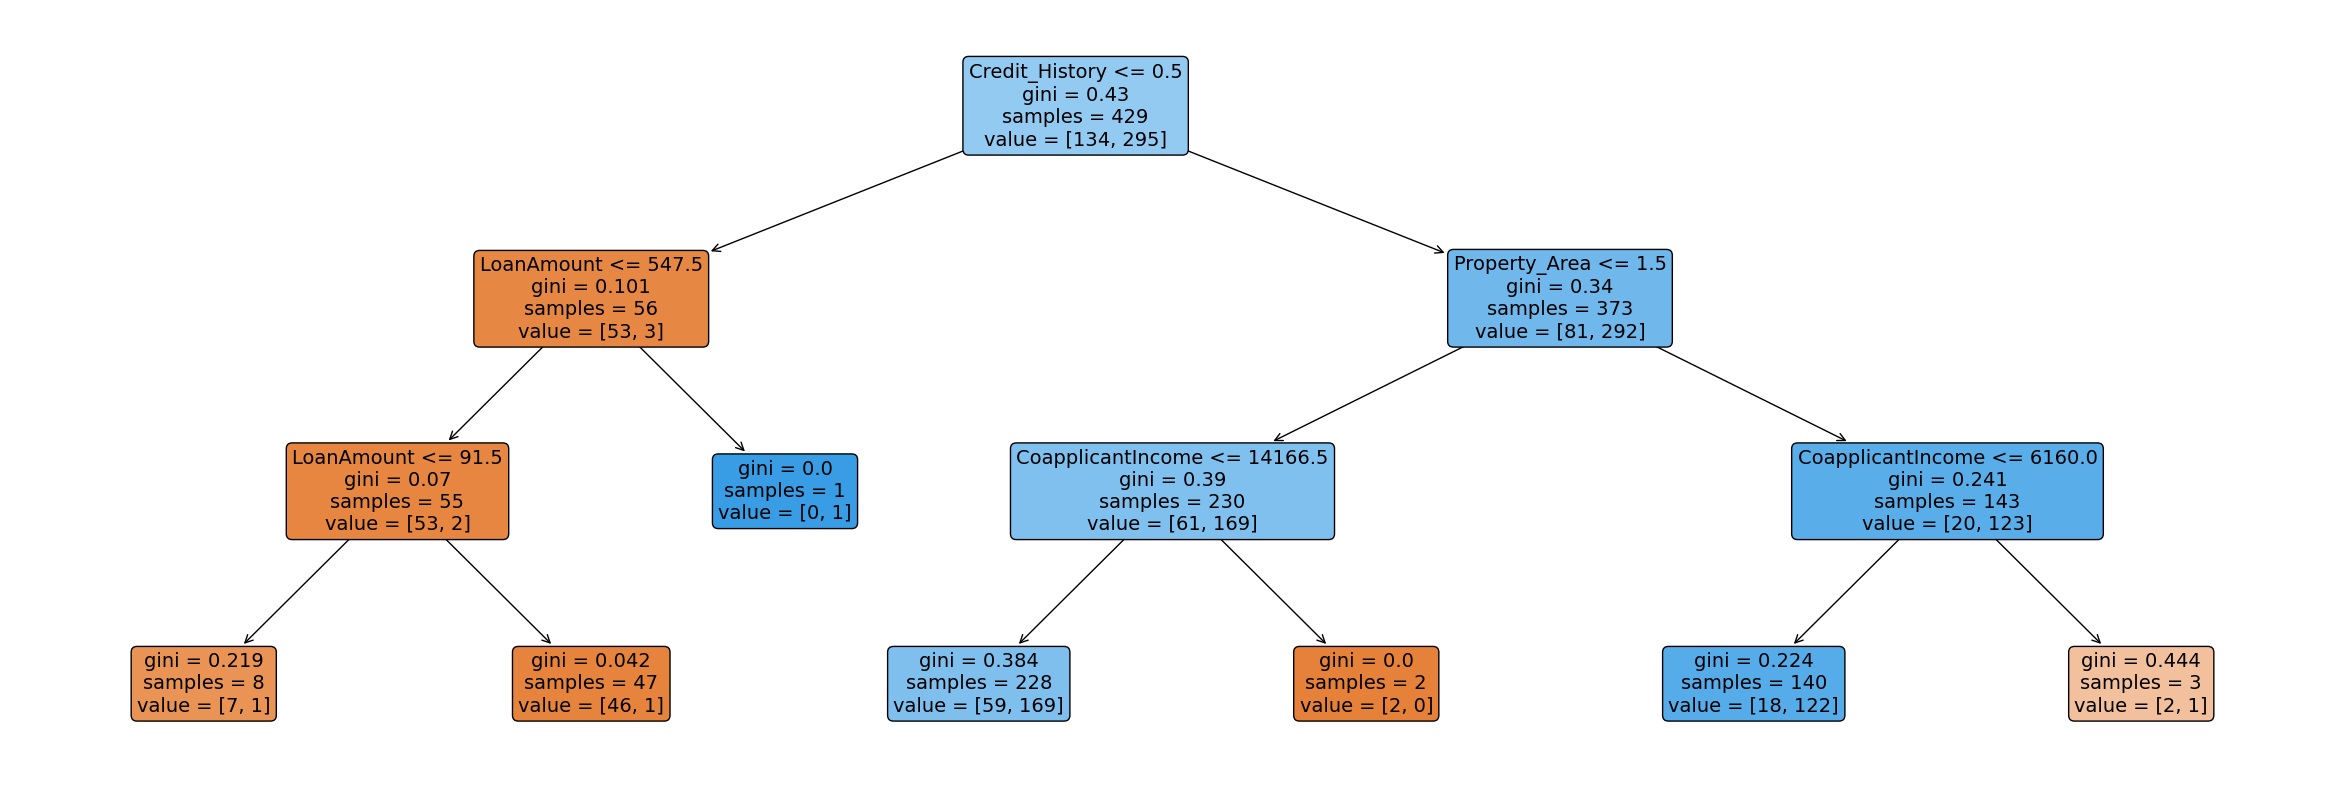

In [36]:
## Trực quan hóa dữ liệu cho cây của Model 1
plt.figure(figsize=(30,10))
a = tree.plot_tree(dtclf,
                   feature_names = X_train.columns.tolist(),
                   rounded = True,
                   filled = True,
                   fontsize=14)

plt.show()

In [37]:
## Precision và Recall Score
print("Precision của Model: "+ str(precision_score(Y_test, dtclf.fit(X_train, Y_train).predict(X_test))))
print("Recall Scorce của Model:" +str(recall_score(Y_test, dtclf.fit(X_train, Y_train).predict(X_test))))

## AUC
print("AUC của Model: "+ str(roc_auc_score(Y_test, dtclf.fit(X_train, Y_train).predict(X_test))))

Precision của Model: 0.8187919463087249
Recall Scorce của Model:0.9606299212598425
AUC của Model: 0.747556339940266


Accuracy của Model: 82.7


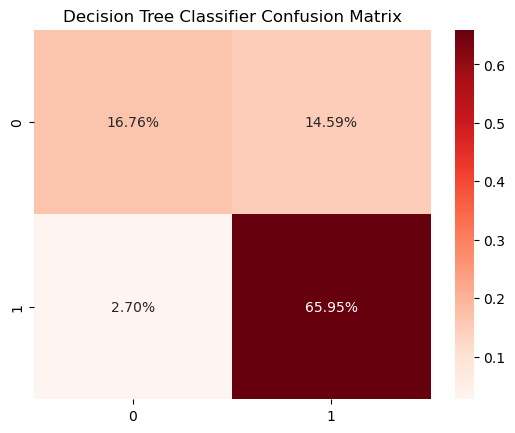

In [38]:
## Accuracy của Model
dt = round(accuracy_score(Y_test, dtclf.fit(X_train, Y_train).predict(X_test))*100,2)
print("Accuracy của Model: "+ str(dt))

# confusion Maxtrix
pred_dt = dtclf.predict(X_test)
cm2 = confusion_matrix(Y_test, pred_dt)
sns.heatmap(cm2/np.sum(cm2), annot = True, fmt=  '0.2%', cmap = 'Reds')
plt.title("Decision Tree Classifier Confusion Matrix",fontsize=12)
plt.show()

Số lượng LoanAmount "Yes" và "No" được dự báo đúng nhiều hơn hẳn số lượng các dự báo có kết quả sai

### 3.3. XGBoost Classifier

In [39]:
!pip install xgboost
from xgboost import XGBClassifier
model_xgb = XGBClassifier(max_depth= 8, n_estimators= 125, random_state= 0,  learning_rate= 0.03, n_jobs=5)

# Training Model
model_xgb.fit(X_train, Y_train)

# Making Prediction
pred_xgb = model_xgb.predict(X_test)

# Calculating Accuracy Score
xgb = round(accuracy_score(Y_test, pred_xgb)*100, 2)
print(xgb)


78.38


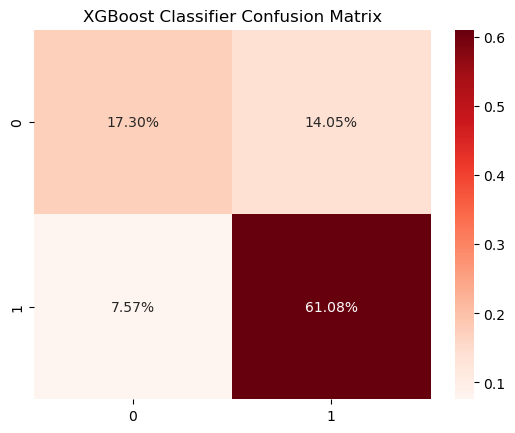

In [40]:
cm3 = confusion_matrix(Y_test, pred_xgb)
sns.heatmap(cm3/np.sum(cm3), annot = True, fmt=  '0.2%', cmap = 'Reds')
plt.title("XGBoost Classifier Confusion Matrix",fontsize=12)
plt.show()

Số lượng LoanAmount "Yes" và "No" được dự báo đúng nhiều hơn hẳn số lượng các dự báo có kết quả sai

### 3.4. KNeighbours


D:\Anaconda\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


65.95


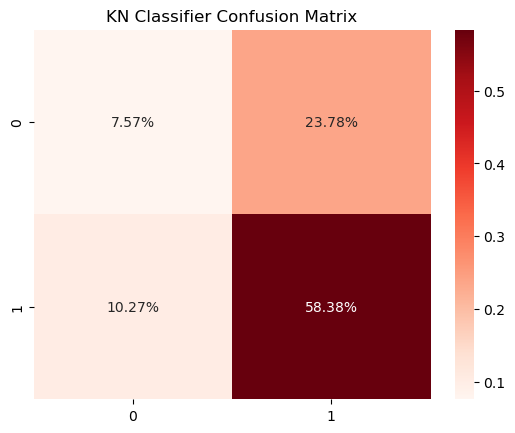

In [41]:
# Creating model object
from sklearn.neighbors import KNeighborsClassifier
model_kn = KNeighborsClassifier(n_neighbors=10, leaf_size=20)

# Training Model
model_kn.fit(X_train, Y_train)

# Making Prediction
pred_kn = model_kn.predict(X_test)

# Calculating Accuracy Score
kn = round(accuracy_score(Y_test, pred_kn)*100, 2)
print(kn)

# confusion Maxtrix
cm4 = confusion_matrix(Y_test, pred_kn)
sns.heatmap(cm4/np.sum(cm4), annot = True, fmt=  '0.2%', cmap = 'Reds')
plt.title("KN Classifier Confusion Matrix",fontsize=12)
plt.show()

Số lượng LoanAmount "Yes" và "No" được dự báo đúng nhiều hơn hẳn số lượng các dự báo có kết quả sai

### 3.5. SVM

68.11


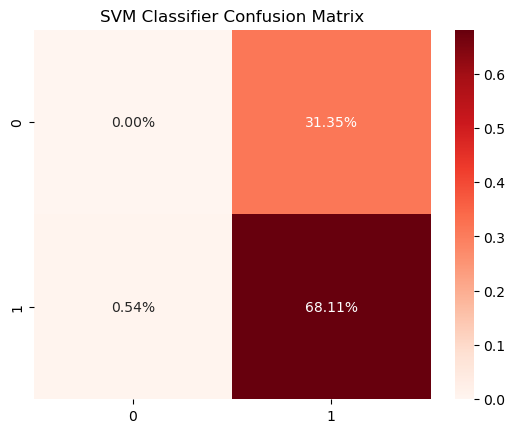

In [42]:
# creating model object
from sklearn.svm import SVC
model_svm = SVC(kernel='rbf', random_state = 42)

# Training model
model_svm.fit(X_train, Y_train)

# Making Prediction
pred_svm = model_svm.predict(X_test)

# Calculating Accuracy Score
sv = round(accuracy_score(Y_test, pred_svm)*100, 2)
print(sv)

# confusion Maxtrix
cm6 = confusion_matrix(Y_test, pred_svm)
sns.heatmap(cm6/np.sum(cm6), annot = True, fmt=  '0.2%', cmap = 'Reds')
plt.title("SVM Classifier Confusion Matrix",fontsize=12)
plt.show()

Số lượng LoanAmount "Yes" và "No" được dự báo đúng nhiều hơn hẳn số lượng các dự báo có kết quả sai

### 3.6. AdaBoost Classifier

82.16


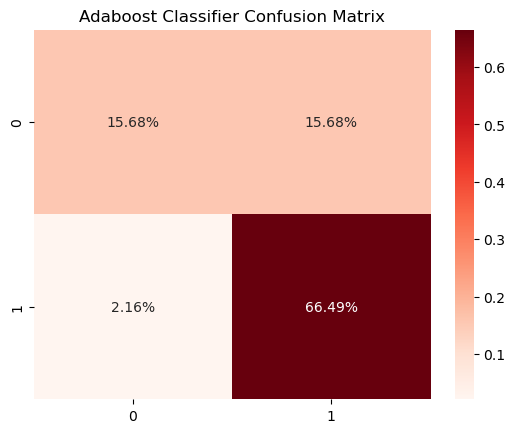

In [43]:
# Creating model object 
from sklearn.ensemble import AdaBoostClassifier
model_ada = AdaBoostClassifier(learning_rate= 0.002,n_estimators= 205,random_state=42)

# Training model
model_ada.fit(X_train, Y_train)

# Making Prediction
pred_ada = model_ada.predict(X_test)

# Calculating Accuracy Score
ada = round(accuracy_score(Y_test, pred_ada)*100, 2)
print(ada)

# confusion Maxtrix
cm7 = confusion_matrix(Y_test, pred_ada)
sns.heatmap(cm7/np.sum(cm7), annot = True, fmt=  '0.2%', cmap = 'Reds')
plt.title("Adaboost Classifier Confusion Matrix",fontsize=12)
plt.show()

Số lượng LoanAmount "Yes" và "No" được dự báo đúng nhiều hơn hẳn số lượng các dự báo có kết quả sai

### 3.7. So sánh Models

,Model,Accuracy_score
1,Decision Tree,82.70
5,AdaBoost,82.16
0,Logistics Regression,81.62
2,XGBoost,78.38
4,SVM,68.11
3,KNeighbours,65.95


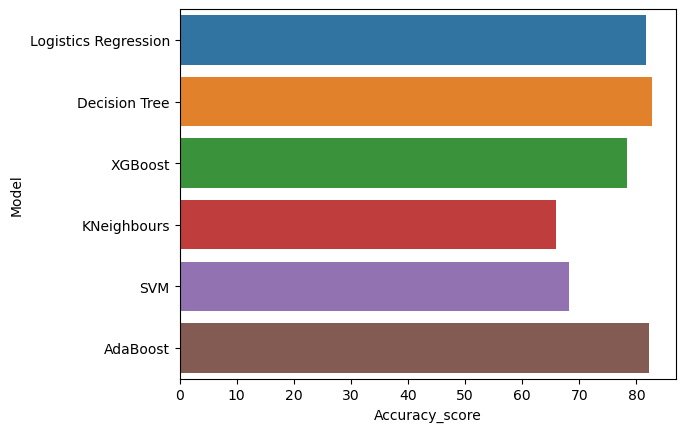

In [44]:
models = pd.DataFrame({
    'Model':['Logistics Regression', 'Decision Tree', 'XGBoost', 'KNeighbours', 'SVM', 'AdaBoost'],
    'Accuracy_score' :[log, dt, xgb, kn, sv, ada]
})
models
sns.barplot(x='Accuracy_score', y='Model', data=models)

models.sort_values(by='Accuracy_score', ascending=False)

**Vậy Decision Tree là mô hình phù hợp nhất**

In [45]:
#Kiểm tra các Metrics khác:Precision, Recall, ROC Curve, AUC Curve

# Calculate precision of Logistic Regression
precision = precision_score(Y_test, Y_predict)
print("Precision của Logistic Regression:", precision)


print()

# Calculate recall of Logistic Regression
recall = recall_score(Y_test, Y_predict)
print("Recall của Logistic Regression:", recall)

print()

#Calculate AUC of Logistic Regression
print("AUC của Logistic Regression:", roc_auc_score(Y_test, Y_predict))


NameError: name 'Y_predict' is not defined

In [ ]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Dự đoán trên tập Test
Y_pred = dtclf.predict(X_test)

# Tính toán Precision
precision = precision_score(Y_test, Y_pred)
print("Precision của Decision Tree:", precision)

# Tính toán Recall
recall = recall_score(Y_test, Y_pred)
print("Recall của Decision Tree:", recall)

# Tính toán AUC
auc = roc_auc_score(Y_test, Y_pred)
print("AUC của Decision Tree:", auc)

Từ kết quả trên, ta thấy: 
- Precision log < Precision Dt
- AUC log < AUC Dt

### Kết luận: Decision Tree là model tốt nhất để đưa ra dự đoán cho khách hàng mới về tình trạng vay**

# Tài liệu tham khảo

1. Bekhet, H. A., & Eletter, S. F. K., 2014. Credit risk assessment model for Jordanian commercial banks: Neural scoring approach. Review of Development Finance, 4(1), 20-28.
2. Birhanu, Lakew, 1999, “Micro Enterprise Credil and Poverty Alleviation In Ethiopia: The Case of the Project Office for the Creation of Small Scale Business Opportunities (POCSSBO) in Addis Ababa”, Masters Thesis. Addis Ababa University.
3. C.A. Wongnaa, D. Awunyo - Victor, 2013. Factor affecting Loan Repayment Performance among Yam Farmers in the Sene District, Ghana. Agris on-lone papers in Economics and Informatics, Number 2, 1013, pp.112-122.
4. Kohansal, M.R. và Mansoori, H., 2009. Factors affecting on loan repayment performance of farmers in Khorasan-Razavi province of Iran. In Conference on International Research on Food Security, Natural Réource Management and Rural Development, University of Hamburg (pp.1-4)
5. S. U. Isitor và cộng sự, 2016. Các yếu tố quyết định việc hoàn trả khoản vay của nông dân hợp tác xã Smaill ở Phân khu Remo, Bang Ogun, Nigeria. Jpurnal Khoa học Nông nghiệp, tập 8, số 1,2016, trang 92-99.